# Data Analysis, Visualisation and Preprocessing

This notebook loads and analyses the three raw data files used in the COS30019 Assignment 2B project:

1. `Scats Data October 2006.xls`
2. `SCATSSiteListingSpreadsheet_VicRoads.xls`
3. `Traffic_Count_Locations_with_LONG_LAT.csv`

Main goals:

- Load the raw files.
- Explore data quality.
- Visualise useful patterns.
- Decide which files need preprocessing before being used in the project.


# 1. Setup

In [27]:
from pathlib import Path
import sys
import subprocess
import os
import re

# Install missing packages for this notebook kernel
required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "xlrd"
]

for package in required_packages:
    try:
        __import__(package)
    except ModuleNotFoundError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

BASE_DIR = Path.cwd()

print("Current working directory:", BASE_DIR)

Current working directory: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data


In [28]:
from pathlib import Path

BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "raws"

traffic_file = RAW_DIR / "Scats Data October 2006.xls"
site_listing_file = RAW_DIR / "SCATSSiteListingSpreadsheet_VicRoads.xls"
locations_file = RAW_DIR / "Traffic_Count_Locations_with_LONG_LAT.csv"

# Check files exist
for file_path in [traffic_file, site_listing_file, locations_file]:
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

print("Traffic data file:", traffic_file)
print("SCATS site listing file:", site_listing_file)
print("Traffic count locations file:", locations_file)

Traffic data file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/raws/Scats Data October 2006.xls
SCATS site listing file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/raws/SCATSSiteListingSpreadsheet_VicRoads.xls
Traffic count locations file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/raws/Traffic_Count_Locations_with_LONG_LAT.csv


# 2. SCATS Traffic Flow Data

File: ```text Scats Data October 2006.xls ```

This is the main dataset for model training. It contains 96 traffic readings per day, where each reading represents a 15-minute interval.


In [30]:
# Load the main traffic data.
traffic_raw = pd.read_excel(traffic_file, sheet_name="Data", header=1)

print("Traffic raw shape:", traffic_raw.shape)
display(traffic_raw.head())


Traffic raw shape: (4192, 106)


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01 00:15:00,86,83,52,58,59,44,31,37,30,24,16,24,25,25,15,6,21,17,15,15,16,21,27,21,25,32,61,48,56,66,77,79,67,93,103,130,154,149,210,229,250,246,266,254,300,275,322,292,315,314,308,280,357,298,281,289,345,297,233,227,273,225,265,257,233,244,259,264,265,253,243,210,216,202,177,169,167,136,131,128,118,121,87,113,142,112,114,97,97,66,81,50,59,47,29,34
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02 00:15:00,32,28,17,11,7,11,6,15,11,12,6,9,1,4,11,9,11,16,22,14,28,26,57,57,70,136,221,196,239,366,355,400,401,400,395,367,315,308,302,306,245,286,279,275,227,234,236,239,320,254,242,261,251,290,254,256,283,226,276,271,281,285,306,301,327,340,294,326,277,382,320,377,259,298,218,190,186,172,161,158,134,141,119,142,103,108,111,102,107,114,80,60,62,48,44,26
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03 00:15:00,26,32,21,14,10,12,13,10,9,7,8,5,5,6,11,12,8,11,13,10,23,37,64,95,90,183,219,251,302,307,410,351,411,408,405,372,330,366,360,317,312,289,293,299,293,273,264,264,290,260,286,272,274,270,259,313,281,347,280,266,347,277,328,318,357,347,381,288,358,338,365,369,296,335,269,232,211,198,176,163,155,140,135,129,139,146,130,132,114,86,93,90,73,57,29,40
3,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04 00:15:00,32,22,28,13,16,8,14,10,8,8,7,6,8,2,7,10,8,14,16,12,24,37,62,84,82,166,230,235,256,336,316,392,374,392,417,380,376,328,324,338,282,272,290,340,301,288,258,272,319,315,251,281,294,301,300,288,282,260,247,252,320,300,264,329,359,345,270,338,308,340,377,335,352,290,258,281,237,203,167,165,133,163,135,141,137,158,115,113,132,101,113,90,78,66,52,44
4,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05 00:15:00,40,39,21,11,16,9,15,15,9,6,9,4,4,1,11,9,17,13,16,15,23,35,58,79,81,139,238,235,235,328,344,315,359,434,375,365,356,362,328,330,327,276,311,281,303,324,285,301,331,296,302,299,290,281,308,294,303,296,265,306,312,322,343,317,397,385,388,324,348,361,372,396,315,334,309,271,251,262,228,196,176,152,146,167,122,150,171,120,116,113,99,91,61,55,49,36


In [18]:
# Basic data quality check
print("Columns:", traffic_raw.columns.tolist()[:15], "...")

v_cols = [c for c in traffic_raw.columns if isinstance(c, str) and re.fullmatch(r"V\d{2}", c)]
print("Number of 15-minute interval columns:", len(v_cols))
print("First interval columns:", v_cols[:5])
print("Last interval columns:", v_cols[-5:])

print("\nUnique SCATS sites:", traffic_raw["SCATS Number"].nunique())
print("Date range:", traffic_raw["Date"].min(), "to", traffic_raw["Date"].max())
print("Rows:", len(traffic_raw))

print("\nMissing values in key columns:")
display(traffic_raw[["SCATS Number", "Location", "NB_LATITUDE", "NB_LONGITUDE", "Date"]].isna().sum())

print("\nMissing values in traffic interval columns:")
display(traffic_raw[v_cols].isna().sum().sort_values(ascending=False).head(10))

print("\nTraffic value summary:")
display(traffic_raw[v_cols].describe().T[["min", "mean", "max"]].head())


Columns: ['SCATS Number', 'Location', 'CD_MELWAY', 'NB_LATITUDE', 'NB_LONGITUDE', 'HF VicRoads Internal', 'VR Internal Stat', 'VR Internal Loc', 'NB_TYPE_SURVEY', 'Date', 'V00', 'V01', 'V02', 'V03', 'V04'] ...
Number of 15-minute interval columns: 96
First interval columns: ['V00', 'V01', 'V02', 'V03', 'V04']
Last interval columns: ['V91', 'V92', 'V93', 'V94', 'V95']

Unique SCATS sites: 40
Date range: 2006-10-01 00:15:00 to 2006-10-31 00:15:00
Rows: 4192

Missing values in key columns:


SCATS Number    0
Location        0
NB_LATITUDE     0
NB_LONGITUDE    0
Date            0
dtype: int64


Missing values in traffic interval columns:


V00    0
V01    0
V70    0
V69    0
V68    0
V67    0
V66    0
V65    0
V64    0
V63    0
dtype: int64


Traffic value summary:


,min,mean,max
V00,0.0,34.049380,304.0
V01,0.0,30.185592,252.0
V02,0.0,25.936307,201.0
V03,0.0,22.516937,281.0
V04,0.0,19.607109,247.0


In [19]:
# Convert wide format to long time-series format.
traffic_long = traffic_raw.melt(
    id_vars=["SCATS Number", "Location", "NB_LATITUDE", "NB_LONGITUDE", "Date"],
    value_vars=v_cols,
    var_name="interval_code",
    value_name="flow"
)

traffic_long["site_id"] = (
    traffic_long["SCATS Number"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
)

traffic_long["date_only"] = pd.to_datetime(traffic_long["Date"]).dt.date
traffic_long["interval"] = traffic_long["interval_code"].str.extract(r"V(\d{2})").astype(int)
traffic_long["time"] = pd.to_timedelta(traffic_long["interval"] * 15, unit="m")
traffic_long["timestamp"] = pd.to_datetime(traffic_long["date_only"].astype(str)) + traffic_long["time"]

# Aggregate traffic flow by SCATS site and timestamp only.
# This sums all detector/direction records into one total flow value per intersection per 15-minute interval.
flow_agg = (
    traffic_long
    .groupby(["site_id", "date_only", "interval", "timestamp"], as_index=False)["flow"]
    .sum()
)

# Keep one representative location and average coordinates for each SCATS site.
site_info = (
    traffic_long
    .groupby("site_id", as_index=False)
    .agg({
        "Location": "first",
        "NB_LATITUDE": "mean",
        "NB_LONGITUDE": "mean"
    })
)

traffic_ts = flow_agg.merge(site_info, on="site_id", how="left")

traffic_ts = traffic_ts[
    ["site_id", "Location", "NB_LATITUDE", "NB_LONGITUDE", "date_only", "interval", "timestamp", "flow"]
].sort_values(["site_id", "timestamp"])

print("Long raw shape:", traffic_long.shape)
print("Aggregated time-series shape:", traffic_ts.shape)
display(traffic_ts.head())

Long raw shape: (402432, 12)
Aggregated time-series shape: (116160, 8)


,site_id,Location,NB_LATITUDE,NB_LONGITUDE,date_only,interval,timestamp,flow
0,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,0,2006-10-01 00:00:00,262
1,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,1,2006-10-01 00:15:00,248
2,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,2,2006-10-01 00:30:00,199
3,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,3,2006-10-01 00:45:00,176
4,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,4,2006-10-01 01:00:00,177


In [20]:
# Data mining summary for traffic flow
print("Number of sites:", traffic_ts["site_id"].nunique())
print("Number of dates:", traffic_ts["date_only"].nunique())
print("Number of intervals per day:", traffic_ts["interval"].nunique())
print("Total zero flow records:", (traffic_ts["flow"] == 0).sum())
print("Missing flow records:", traffic_ts["flow"].isna().sum())

site_summary = traffic_ts.groupby("site_id")["flow"].agg(["count", "mean", "min", "max", "std"]).reset_index()
display(site_summary.sort_values("mean", ascending=False).head(10))

daily_summary = traffic_ts.groupby("date_only")["flow"].agg(["mean", "sum", "max"]).reset_index()
display(daily_summary.head())


Number of sites: 40
Number of dates: 31
Number of intervals per day: 96
Total zero flow records: 94
Missing flow records: 0


,site_id,count,mean,min,max,std
1,2000,2784,616.851652,13,1409,408.201703
0,0970,2976,584.314516,0,1332,412.440780
24,4043,2976,536.963374,18,1151,330.529419
8,3002,2496,483.794872,0,1103,322.659499
5,2827,2976,483.756384,12,1295,330.442509
9,3120,2976,482.444556,93,974,245.467223
29,4263,2496,458.769231,16,1028,294.667730
21,4034,2976,454.466398,0,1028,290.663038
31,4266,2976,451.945901,0,1037,296.131477
14,3662,2976,442.295699,0,1057,288.734062


,date_only,mean,sum,max
0,2006-10-01,277.184829,1037780,1135
1,2006-10-02,361.132031,1386747,1396
2,2006-10-03,383.582031,1472955,1347
3,2006-10-04,379.958594,1459041,1344
4,2006-10-05,393.074479,1509406,1374


## 2.1 Traffic Flow Visualisation

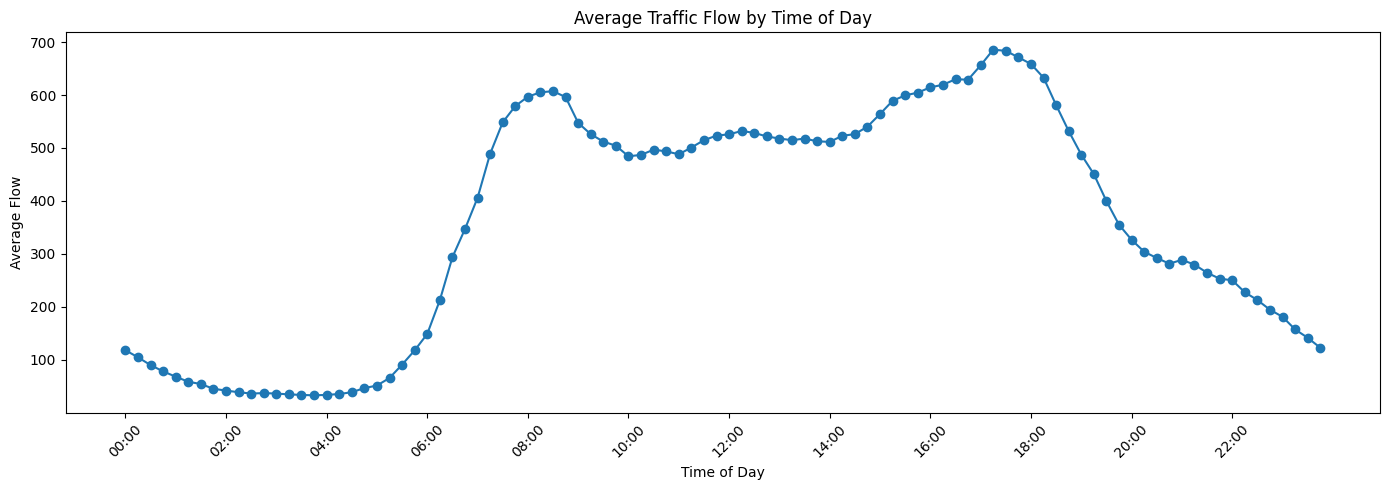

In [21]:
# Average traffic flow by time of day
avg_by_interval = traffic_ts.groupby("interval")["flow"].mean().reset_index()
avg_by_interval["time_label"] = (pd.to_datetime("2000-01-01") + pd.to_timedelta(avg_by_interval["interval"] * 15, unit="m")).dt.strftime("%H:%M")

plt.figure(figsize=(14, 5))
plt.plot(avg_by_interval["interval"], avg_by_interval["flow"], marker="o")
plt.xticks(avg_by_interval["interval"][::8], avg_by_interval["time_label"][::8], rotation=45)
plt.title("Average Traffic Flow by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Flow")
plt.tight_layout()
plt.show()


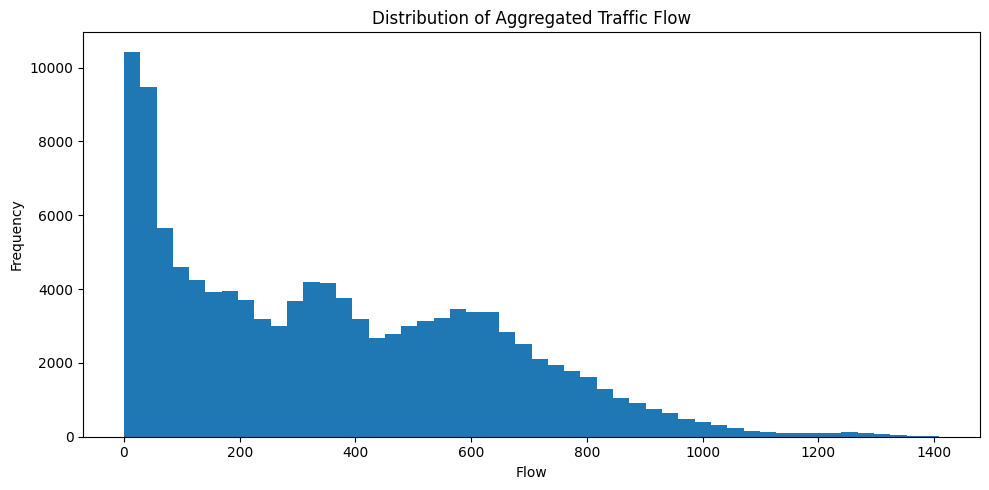

In [22]:
# Traffic distribution
plt.figure(figsize=(10, 5))
plt.hist(traffic_ts["flow"].dropna(), bins=50)
plt.title("Distribution of Aggregated Traffic Flow")
plt.xlabel("Flow")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


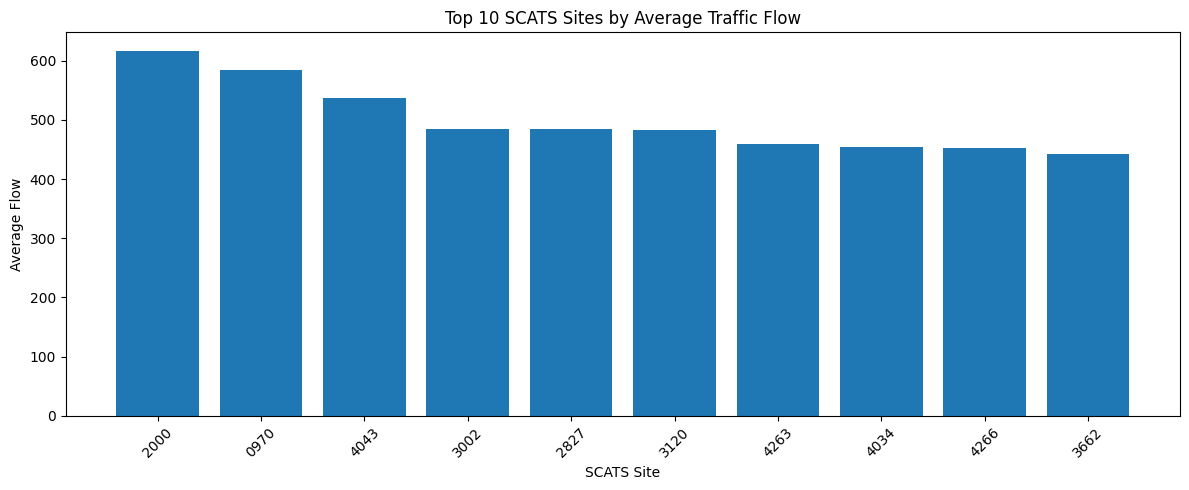

In [23]:
# Top 10 sites by average traffic
top_sites = site_summary.sort_values("mean", ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_sites["site_id"], top_sites["mean"])
plt.title("Top 10 SCATS Sites by Average Traffic Flow")
plt.xlabel("SCATS Site")
plt.ylabel("Average Flow")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


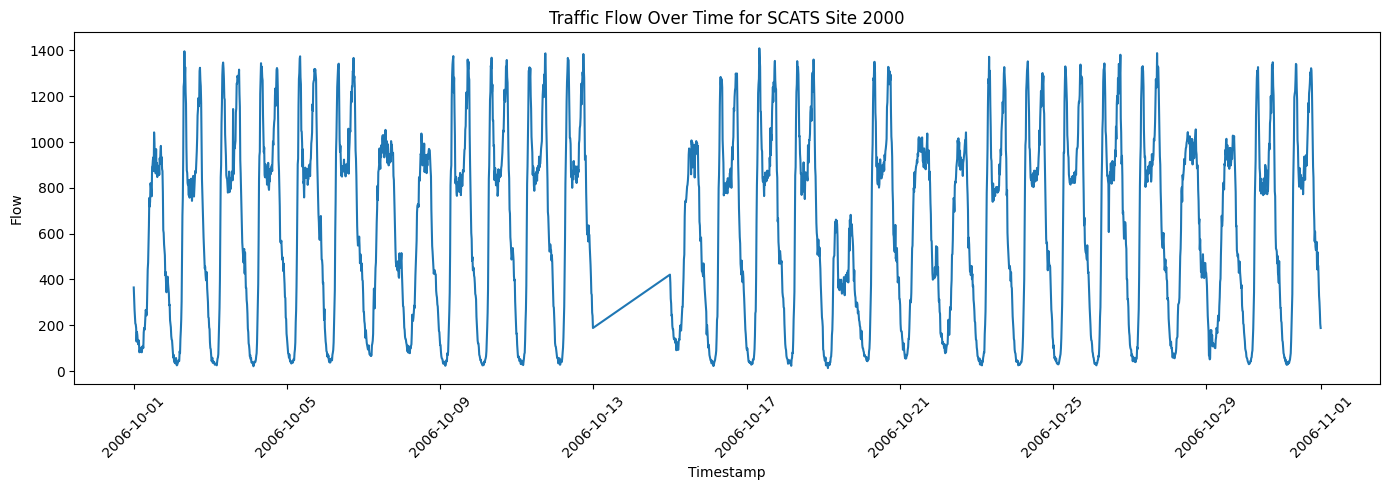

In [24]:
# Example one-site time series
example_site = site_summary.sort_values("mean", ascending=False)["site_id"].iloc[0]
example_data = traffic_ts[traffic_ts["site_id"] == example_site].sort_values("timestamp")

plt.figure(figsize=(14, 5))
plt.plot(example_data["timestamp"], example_data["flow"])
plt.title(f"Traffic Flow Over Time for SCATS Site {example_site}")
plt.xlabel("Timestamp")
plt.ylabel("Flow")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 3. SCATS Site Listing Data

File:``` text SCATSSiteListingSpreadsheet_VicRoads.xls ```

This file is metadata. It is useful for mapping SCATS site numbers to intersection names.


In [31]:
# 3. SCATS Site Listing Data
# Use the site_listing_file path already loaded in Section 1

import sys
import subprocess

# Install calamine engine if it is not available in this notebook kernel
try:
    import python_calamine
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-calamine"])
    import python_calamine

print("Using SCATS site listing file:")
print(site_listing_file)

if not site_listing_file.exists():
    raise FileNotFoundError(f"File not found: {site_listing_file}")

# Read sheet names using calamine instead of xlrd
xls = pd.ExcelFile(site_listing_file, engine="calamine")

print("Available sheets:")
print(xls.sheet_names)

def load_site_listing(path):
    sheet_name = "SCATS Site Numbers"

    site_df = pd.read_excel(
        path,
        sheet_name=sheet_name,
        header=9,
        engine="calamine"
    )

    site_df = site_df.dropna(how="all")

    site_df.columns = (
        site_df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    if "site_number" in site_df.columns:
        site_df["site_id"] = (
            site_df["site_number"]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
            .str.strip()
            .str.zfill(4)
        )

    return site_df

site_listing = load_site_listing(site_listing_file)

print("Site listing shape:", site_listing.shape)
display(site_listing.head())
display(site_listing.info())

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Using SCATS site listing file:
/Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/raws/SCATSSiteListingSpreadsheet_VicRoads.xls
Available sheets:
['Data Infomation', 'SCATS Site Numbers']
Site listing shape: (4515, 6)


,site_number,location_description,site_type,directory,map_reference,site_id
0,964,ABBOTTS/CLELANDS DEVELOPMENTS,INT,Melway,095G08,0964
1,968,ABBOTTS/GAINE/MONASH,INT,Melway,095K08,0968
2,972,ABBOTTS/NATIONAL,INT,Melway,95J08,0972
3,983,ABBOTTS/REMINGTON,INT,Melway,095G08,0983
4,1053,ABBOTTSFORD/HAINES,INT,Melway,2A-G07,1053


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4515 entries, 0 to 4514
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   site_number           4515 non-null   int64 
 1   location_description  4515 non-null   object
 2   site_type             4515 non-null   object
 3   directory             4313 non-null   object
 4   map_reference         4174 non-null   object
 5   site_id               4515 non-null   object
dtypes: int64(1), object(5)
memory usage: 211.8+ KB


None

In [ ]:
# Site listing data quality
print("Columns:", site_listing.columns.tolist())

if "site_id" in site_listing.columns:
    print("Unique site IDs:", site_listing["site_id"].nunique())
    print("Duplicated site IDs:", site_listing["site_id"].duplicated().sum())
    display(site_listing[site_listing["site_id"].duplicated(keep=False)].head(10))

print("\nMissing values:")
display(site_listing.isna().sum())

# Check how many traffic sites appear in site listing.
traffic_site_ids = set(traffic_ts["site_id"].unique())
listing_site_ids = set(site_listing["site_id"].dropna().unique())

matched_sites = traffic_site_ids.intersection(listing_site_ids)
missing_in_listing = sorted(traffic_site_ids - listing_site_ids)

print("Traffic sites:", len(traffic_site_ids))
print("Matched in site listing:", len(matched_sites))
print("Missing from site listing:", missing_in_listing[:20])


## 3.1 Site Listing Visualisation

In [ ]:
# Site type counts
if "site_type" in site_listing.columns:
    site_type_counts = site_listing["site_type"].value_counts(dropna=False)
    display(site_type_counts.head(10))

    plt.figure(figsize=(8, 5))
    site_type_counts.head(10).plot(kind="bar")
    plt.title("SCATS Site Listing: Site Type Counts")
    plt.xlabel("Site Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
# Save cleaned site listing.
site_listing_clean = site_listing.copy()

keep_cols = [c for c in ["site_id", "site_number", "location_description", "site_type", "directory", "map_reference"] if c in site_listing_clean.columns]
site_listing_clean = site_listing_clean[keep_cols].drop_duplicates()

site_listing_clean.to_csv(PROCESSED_DIR / "scats_site_listing_clean.csv", index=False)

print("Saved:", PROCESSED_DIR / "scats_site_listing_clean.csv")
display(site_listing_clean.head())


# 4. Traffic Count Locations Data

File:

```text
Traffic_Count_Locations_with_LONG_LAT.csv
```

This file contains longitude/latitude and traffic count location metadata. It can be used for map exploration, distance checking, or optional route visualisation.

Important: do not assume `TFM_ID` always equals `SCATS Number` without checking.


In [ ]:
locations_raw = pd.read_csv(locations_file)

print("Locations raw shape:", locations_raw.shape)
display(locations_raw.head())
display(locations_raw.info())


In [ ]:
# Clean column names
locations = locations_raw.copy()
locations.columns = (
    locations.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

rename_map = {
    "x": "longitude",
    "y": "latitude",
    "tfm_id": "tfm_id",
    "tfm_desc": "tfm_desc",
    "site_desc": "site_desc",
    "aadt_allve": "aadt_all_vehicles",
    "aadt_truck": "aadt_truck",
    "per_trucks": "percent_trucks",
}
locations = locations.rename(columns=rename_map)

if "tfm_id" in locations.columns:
    locations["tfm_id"] = locations["tfm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

print("Cleaned columns:", locations.columns.tolist())
display(locations.head())


In [ ]:
# Location data quality checks
print("Rows:", len(locations))
print("Columns:", len(locations.columns))

for col in ["tfm_id", "longitude", "latitude"]:
    if col in locations.columns:
        print(f"{col}: missing =", locations[col].isna().sum())

if "tfm_id" in locations.columns:
    print("Unique TFM IDs:", locations["tfm_id"].nunique())
    print("Duplicated TFM IDs:", locations["tfm_id"].duplicated().sum())

if {"longitude", "latitude"}.issubset(locations.columns):
    print("\nCoordinate summary:")
    display(locations[["longitude", "latitude"]].describe())

if "aadt_all_vehicles" in locations.columns:
    print("\nAADT summary:")
    display(locations["aadt_all_vehicles"].describe())

if "tfm_id" in locations.columns:
    location_ids = set(locations["tfm_id"].dropna().unique())
    direct_matches = traffic_site_ids.intersection(location_ids)
    not_matched = sorted(traffic_site_ids - location_ids)

    print("Traffic SCATS sites:", len(traffic_site_ids))
    print("Direct matches with TFM_ID:", len(direct_matches))
    print("Traffic SCATS sites not directly matched in TFM_ID:", not_matched)


## 4.1 Traffic Count Location Visualisation

In [ ]:
# Scatter plot of all traffic count locations
if {"longitude", "latitude"}.issubset(locations.columns):
    plot_locations = locations.dropna(subset=["longitude", "latitude"])

    plt.figure(figsize=(8, 8))
    plt.scatter(plot_locations["longitude"], plot_locations["latitude"], s=5, alpha=0.4)
    plt.title("Traffic Count Locations: Longitude/Latitude Scatter Plot")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()


In [ ]:
# Overlay SCATS coordinates extracted from traffic data
if {"longitude", "latitude"}.issubset(locations.columns):
    valid_scats_coords = traffic_coords.copy()
    valid_scats_coords = valid_scats_coords[
        (valid_scats_coords["latitude"].notna()) &
        (valid_scats_coords["longitude"].notna()) &
        ~((valid_scats_coords["latitude"] == 0) & (valid_scats_coords["longitude"] == 0))
    ]

    plt.figure(figsize=(8, 8))
    plt.scatter(plot_locations["longitude"], plot_locations["latitude"], s=5, alpha=0.25, label="Traffic count locations")
    plt.scatter(valid_scats_coords["longitude"], valid_scats_coords["latitude"], s=40, label="SCATS sites from traffic file")
    plt.title("Traffic Count Locations vs SCATS Coordinates from Traffic Data")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("SCATS coordinates with latitude/longitude = 0:")
    display(traffic_coords[(traffic_coords["latitude"] == 0) | (traffic_coords["longitude"] == 0)])


In [ ]:
# AADT distribution
if "aadt_all_vehicles" in locations.columns:
    plt.figure(figsize=(10, 5))
    plt.hist(locations["aadt_all_vehicles"].dropna(), bins=50)
    plt.title("Distribution of AADT All Vehicles")
    plt.xlabel("AADT All Vehicles")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


In [ ]:
# Save cleaned locations data.
location_keep_cols = [
    c for c in [
        "tfm_id", "tfm_desc", "site_desc", "longitude", "latitude",
        "aadt_all_vehicles", "aadt_truck", "percent_trucks",
        "tfm_typ_de", "movement_t"
    ]
    if c in locations.columns
]

locations_clean = locations[location_keep_cols].drop_duplicates()
locations_clean.to_csv(PROCESSED_DIR / "traffic_count_locations_clean.csv", index=False)

print("Saved:", PROCESSED_DIR / "traffic_count_locations_clean.csv")
display(locations_clean.head())
